In [ ]:
!pip install mvlearn==0.5.0 --no-deps
!pip install scikit-learn scipy numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.6 MB/s eta 0:00:00


In [ ]:
pip install POT pymanopt autograd scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.2 MB/s eta 0:00:00


using device=device(type='cuda')


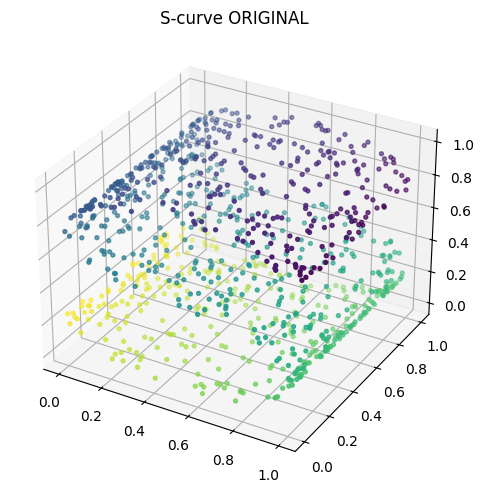

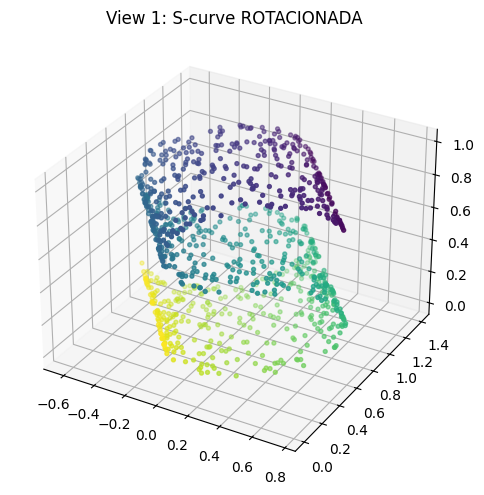

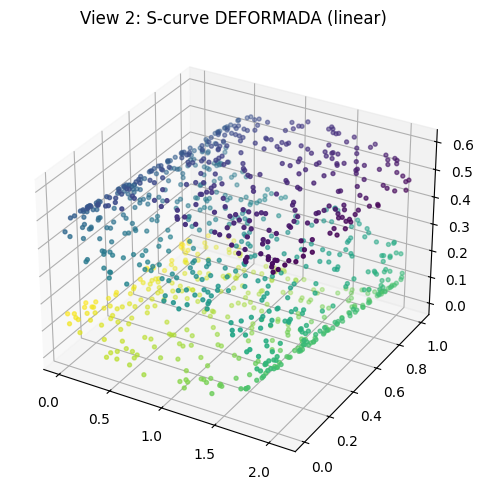

In [ ]:


import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

from sklearn.datasets import make_s_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import Isomap

import ot

# ------------------------------------------------------------
# 0) DISPOSITIVO + SEED
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using {device=}")

np.random.seed(0)
torch.manual_seed(0)

# ------------------------------------------------------------
# 1) GERAR S-CURVE BASE
# ------------------------------------------------------------
n_samples = 1000
X_np, t_np = make_s_curve(n_samples=n_samples, random_state=0)




scaler = MinMaxScaler()
X_np = scaler.fit_transform(X_np)

# labels só pra plot (cor)
labels_np = t_np




# ------------------------------------------------------------
# 2) GERAR 2 VIEWS
# ------------------------------------------------------------
# View 1: rotação
theta = np.deg2rad(40)
R = np.array([
    [ np.cos(theta), -np.sin(theta), 0.0],
    [ np.sin(theta),  np.cos(theta), 0.0],
    [ 0.0,            0.0,           1.0]
], dtype=np.float32)

X_rot_np = X_np @ R.T

# View 2: deformação linear (alongamento + cisalhamento)
A = np.array([
    [1.8, 0.3, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 0.6]
], dtype=np.float32)

X_lin_np = X_np @ A.T

# ------------------------------------------------------------
# 3) (OPCIONAL) VISUALIZAÇÃO DAS VIEWS EM 3D
# ------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_3d(Xv, title):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(Xv[:, 0], Xv[:, 1], Xv[:, 2], c=labels_np, cmap="viridis", s=8)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_3d(X_np,      "S-curve ORIGINAL")
plot_3d(X_rot_np,  "View 1: S-curve ROTACIONADA")
plot_3d(X_lin_np,  "View 2: S-curve DEFORMADA (linear)")


In [ ]:
X_views = [X_rot_np, X_lin_np]

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances
from sklearn.manifold import Isomap

# ------------------------------------------------------------
# DISTÂNCIA PARA N VIEWS
# ------------------------------------------------------------
def compute_multiview_distances(
    X_views,                  # lista: [X_view1, X_view2, ..., X_viewV]
    dist_type="geodesic",     # "euclidean" | "geodesic"
    n_neighbors=12,
    metric="euclidean",
    iso_n_components=2
):
    """
    X_views : lista de arrays (n,d_v)
    retorna:
      DX_list : lista de matrizes (n,n), uma por view
    """
    DX_list = []

    for X_view in X_views:
        if dist_type == "euclidean":
            # DX = pairwise_distances(X_view, metric=metric)
            _x = torch.from_numpy(X_view).float()
            DX = torch.cdist(_x, _x).numpy()

        elif dist_type == "geodesic":
            iso = Isomap(
                n_neighbors=n_neighbors,
                n_components=iso_n_components,
                metric=metric
            )
            iso.fit(X_view)
            DX = np.asarray(iso.dist_matrix_)

        else:
            raise ValueError("dist_type deve ser 'euclidean' ou 'geodesic'")

        DX_list.append(DX)

    return DX_list


# ------------------------------------------------------------
# EXEMPLO DE USO
# ------------------------------------------------------------
# X_views = [X_view1, X_view2, X_view3, ..., X_viewV]

DIST_TYPE = "geodesic"   # troca aqui: "euclidean" | "geodesic"
N_NEIGHBORS = 12

DX_list = compute_multiview_distances(
    X_views,
    dist_type=DIST_TYPE,
    n_neighbors=N_NEIGHBORS
)



In [ ]:
DX1 = DX_list[0]
DX2 = DX_list[1]

rel = np.linalg.norm(DX1 - DX2) / (np.linalg.norm(DX1) + 1e-12)
print("Diferença relativa DX1 vs DX2:", rel)
print("max DX1, DX2:", DX1.max(), DX2.max())


Diferença relativa DX1 vs DX2: 0.2701700491036161
max DX1, DX2: 3.8039558947595125 4.176394033745227


In [ ]:
import numpy as np
import ot

S = len(DX_list)
N = DX_list[0].shape[0]
iter=50

# Cs = [DX.astype(np.float64) for DX in DX_list]

Cs = []
for DX in DX_list:
    DX = DX.astype(np.float64)
    DX = DX / (DX.max() + 1e-12)   # <<< NORMALIZAÇÃO
    Cs.append(DX)

# pesos das views: FORÇA 1D (S,)
lambdas = np.ones(S, dtype=np.float64) / S
lambdas = np.asarray(lambdas, dtype=np.float64).reshape(-1)   # <- garante (S,)

init_C = Cs[0].copy()

D_bar = ot.gromov.gromov_barycenters(
    N, Cs,
    ps=None,
    p=None,
    lambdas=lambdas,
    loss_fun="square_loss",
    symmetric=True,
    max_iter=iter,
    tol=1e-12,
    verbose=True,
    init_C=init_C
)



It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|9.630160e-02|0.000000e+00|0.000000e+00
    1|-6.245005e-17|1.542058e+15|9.630160e-02
    2|-6.245005e-17|0.000000e+00|0.000000e+00
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|9.474607e-02|0.000000e+00|0.000000e+00
    1|6.980609e-02|3.572752e-01|2.493998e-02
    2|3.523499e-02|9.811585e-01|3.457110e-02
    3|7.023951e-03|4.016406e+00|2.821103e-02
    4|6.256699e-03|1.226288e-01|7.672514e-04
    5|6.206844e-03|8.032224e-03|4.985476e-05
    6|6.204422e-03|3.905081e-04|2.422877e-06
    7|6.204098e-03|5.215417e-05|3.235696e-07
    8|6.204098e-03|0.000000e+00|0.000000e+00
It.  |Err         
-------------------
    0|3.938305e+01|
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|9.397281e-02|0.000000e+00|0.000000e+00
    1|6.880699e-02|3.657451e-01|2.516582e-02
    2|1.318914e-02|4.

In [ ]:
print("S =", S, "N =", N)
print("Cs[0] shape:", Cs[0].shape)
print("lambdas shape:", np.asarray(lambdas).shape)
print("lambdas:", lambdas)


S = 2 N = 1000
Cs[0] shape: (1000, 1000)
lambdas shape: (2,)
lambdas: [0.5 0.5]


In [ ]:
# device = 'cpu'

DX_mean = D_bar
DX_mean = torch.from_numpy(DX_mean).float().to(device)

# medida uniforme
n = n_samples
u = torch.ones(n, device=device) / n


d = 2
Y = torch.randn(n, d, device=device, requires_grad=True)

optimizer = torch.optim.Adam([Y], lr=0.1)
num_iterations = 100

hist = {"loss": []}

for it in range(num_iterations):
    optimizer.zero_grad()

    DY = torch.cdist(Y, Y, p=2)  # NÃO NORMALIZAR

    # plano ótimo (sem gradiente)
    with torch.no_grad():
        T = ot.gromov.gromov_wasserstein(
            DX_mean, DY, u, u,
            loss_fun="square_loss",
            verbose=False,
            tol=1e-5
        )

    # loss GW (com grad em DY)
    constC, hX, hY = ot.gromov._utils.init_matrix(
        DX_mean, DY, u, u,
        loss_fun="square_loss"
    )
    loss = ot.gromov._utils.gwloss(constC, hX, hY, T)

    loss.backward()
    optimizer.step()

    hist["loss"].append(loss.item())
    print(f"[{it+1:4d}] Loss={loss.item():.6f}")

/usr/local/lib/python3.12/dist-packages/ot/backend.py:1636: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  jax.device_put(jnp.array(1, dtype=jnp.float64), d),


[   1] Loss=2.522719
[   2] Loss=2.058085
[   3] Loss=1.664902
[   4] Loss=1.338738
[   5] Loss=1.068626
[   6] Loss=0.848675
[   7] Loss=0.669046
[   8] Loss=0.527377
[   9] Loss=0.412555
[  10] Loss=0.320165
[  11] Loss=0.251321
[  12] Loss=0.194618
[  13] Loss=0.152106
[  14] Loss=0.119560
[  15] Loss=0.094047
[  16] Loss=0.074274
[  17] Loss=0.058928
[  18] Loss=0.047828
[  19] Loss=0.038281
[  20] Loss=0.031865
[  21] Loss=0.025829
[  22] Loss=0.021570
[  23] Loss=0.018603
[  24] Loss=0.015470
[  25] Loss=0.013259
[  26] Loss=0.011428
[  27] Loss=0.012050
[  28] Loss=0.010019
[  29] Loss=0.007613
[  30] Loss=0.006726
[  31] Loss=0.005981
[  32] Loss=0.005319
[  33] Loss=0.004750
[  34] Loss=0.004278
[  35] Loss=0.003864
[  36] Loss=0.003501
[  37] Loss=0.003175
[  38] Loss=0.002887
[  39] Loss=0.002617
[  40] Loss=0.002380
[  41] Loss=0.002169
[  42] Loss=0.001980
[  43] Loss=0.001804
[  44] Loss=0.001650
[  45] Loss=0.001517
[  46] Loss=0.001400
[  47] Loss=0.001292
[  48] Loss=0

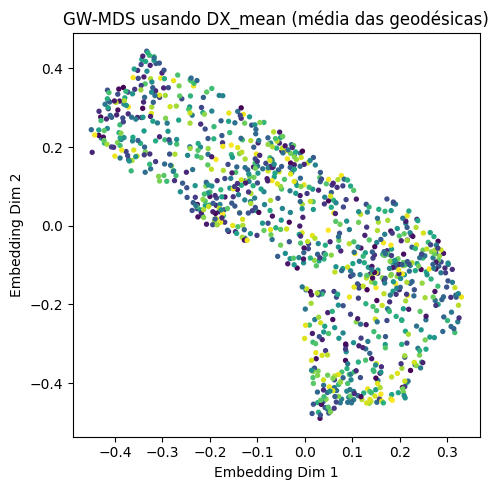

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(Y.detach().cpu()[:, 0], Y.detach().cpu()[:, 1], c=labels_np, s=8, cmap="viridis")
plt.title("GW-MDS usando DX_mean (média das geodésicas)")
plt.xlabel("Embedding Dim 1")
plt.ylabel("Embedding Dim 2")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 7) PROJEÇÃO BARICÊNTRICA FINAL (para visualização)
#    Y_new = T @ Y  (com normalização por linha em T)
# ------------------------------------------------------------
def barycentric_projection(Y_embed, T):
    Y_np_local = Y_embed.detach().cpu().numpy()
    T_np_local = T.detach().cpu().numpy()

    row_sums = T_np_local.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    T_np_local = T_np_local / row_sums

    Y_new_np = T_np_local @ Y_np_local
    return Y_new_np

# recalcula T com DY_final (melhor prática)
DY_final = torch.cdist(Y, Y, p=2)
with torch.no_grad():
    T_final = ot.gromov.gromov_wasserstein(
        DX_mean, DY_final, u, u,
        loss_fun="square_loss",
        verbose=False,
        tol=1e-5
    )



Y_new_np = barycentric_projection(Y, T_final)

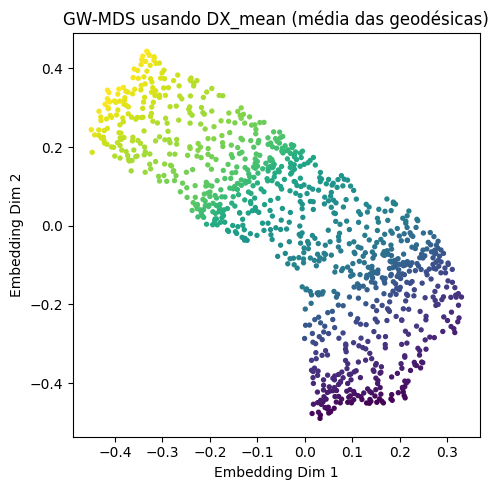

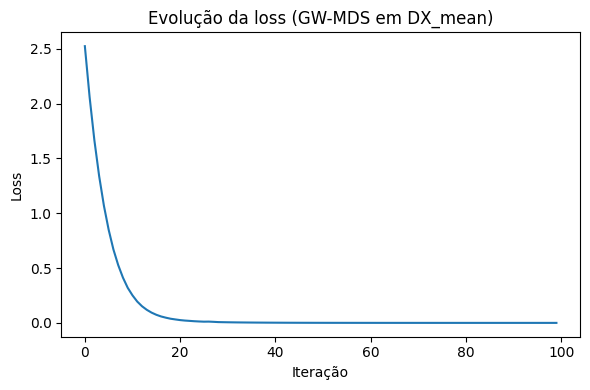

In [ ]:
# ------------------------------------------------------------
# 8) PLOTS: embedding + curva de loss
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
plt.scatter(Y_new_np[:, 0], Y_new_np[:, 1], c=labels_np, s=8, cmap="viridis")
plt.title("GW-MDS usando DX_mean (média das geodésicas)")
plt.xlabel("Embedding Dim 1")
plt.ylabel("Embedding Dim 2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(hist["loss"])
plt.xlabel("Iteração")
plt.ylabel("Loss")
plt.title("Evolução da loss (GW-MDS em DX_mean)")
plt.tight_layout()
plt.show()


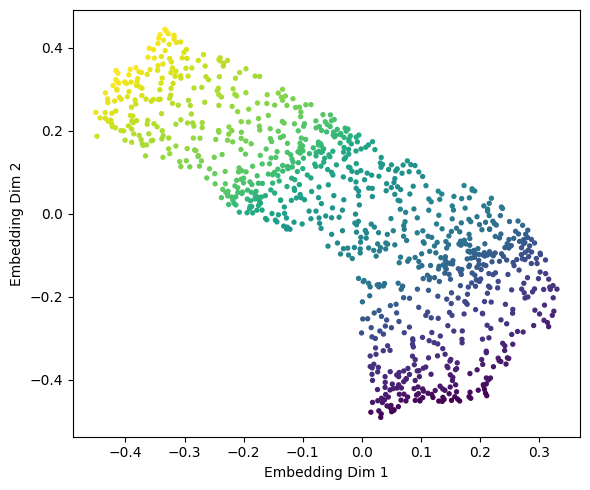

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(Y_new_np[:, 0], Y_new_np[:, 1], c=labels_np, s=8, cmap="viridis")
# plt.title("GW-MDS usando DX_mean (média das geodésicas)")
plt.xlabel("Embedding Dim 1")
plt.ylabel("Embedding Dim 2")
plt.tight_layout()
##############  COLOCAR PARA SALVAR FIGURAS
plt.savefig('Bary-GWMDS SCURVE.pdf', format='pdf')
plt.show()


In [ ]:
import numpy as np

# ------------------------------------------------------------
# 1) DY do embedding FINAL
# ------------------------------------------------------------
DY_new = np.linalg.norm(
    Y_new_np[:, None, :] - Y_new_np[None, :, :],
    axis=2
)

# ------------------------------------------------------------
# 2) DX das views (já podem ser numpy!)
# ------------------------------------------------------------
def to_numpy(X):
    if hasattr(X, "detach"):
        return X.detach().cpu().numpy()
    return X

DX_list_np = [to_numpy(DX) for DX in DX_list]

DX_mean_np = np.mean(DX_list_np, axis=0)

# ------------------------------------------------------------
# 3) Correlação (recomendado: sem diagonal)
# ------------------------------------------------------------
def corr_dist(A, B, remove_diag=True):
    if remove_diag:
        mask = ~np.eye(A.shape[0], dtype=bool)
        return np.corrcoef(A[mask], B[mask])[0, 1]
    return np.corrcoef(A.ravel(), B.ravel())[0, 1]

corr_views = [corr_dist(DY_new, DXv, remove_diag=True) for DXv in DX_list_np]
corr_mean  = corr_dist(DY_new, DX_mean_np, remove_diag=True)

for i, c in enumerate(corr_views, 1):
    print(f"Correlação (Y_new × View {i}): {c}")

print("Correlação (Y_new × DX_mean):", corr_mean)


Correlação (Y_new × View 1): 0.9859320135810642
Correlação (Y_new × View 2): 0.9107009625160335
Correlação (Y_new × DX_mean): 0.9643855880636387
